### Chronic Kidney Disease Model Training

#### Import Libraries

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

sns.set_theme(style="whitegrid")
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

#### Load Preprocessed Data

In [2]:
# Target column for the model.
targetColumn = "ckdDiagnosis"

# Load unscaled feature data for Random Forest and XGBoost.
XTrain = pd.read_csv("dataset/XTrain.csv")
XTest = pd.read_csv("dataset/XTest.csv")

# Load scaled feature data for Logistic Regression.
XTrainScaled = pd.read_csv("dataset/XTrainScaled.csv")
XTestScaled = pd.read_csv("dataset/XTestScaled.csv")

# Load the shared target split.
yTrain = pd.read_csv("dataset/yTrain.csv")[targetColumn]
yTest = pd.read_csv("dataset/yTest.csv")[targetColumn]

#### Create Reusable Evaluation Function to train all 3 models

In [3]:
# Reuseable function to evaluate a model and return its performance metrics and predictions.
def evaluateModel(modelName, model, XTrainData, XTestData, yTrainData, yTestData):

    # Train the model
    startTime = time.time()
    model.fit(XTrainData, yTrainData)
    trainingTimeSeconds = round(time.time() - startTime, 4)

    # Predict class labels and positive class probabilities.
    predictedValues = model.predict(XTestData)
    predictedProbabilities = model.predict_proba(XTestData)[:, 1]

    # Calculate the same evaluation metrics for every model.
    accuracy = accuracy_score(yTestData, predictedValues)
    precision = precision_score(yTestData, predictedValues, zero_division=0)
    recall = recall_score(yTestData, predictedValues, zero_division=0)
    f1Score = f1_score(yTestData, predictedValues, zero_division=0)
    rocAuc = roc_auc_score(yTestData, predictedProbabilities)

    # Print the classification report for the individual model.
    print(f"{modelName} Classification Report")
    print(classification_report(yTestData, predictedValues, zero_division=0))

    # Display a confusion matrix for the individual model.
    confusionMatrix = confusion_matrix(yTestData, predictedValues)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        confusionMatrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No CKD", "CKD"],
        yticklabels=["No CKD", "CKD"]
    )
    plt.title(f"{modelName} Confusion Matrix")
    plt.xlabel("Predicted Value")
    plt.ylabel("Actual Value")
    plt.tight_layout()
    plt.show()

    # Model results and predictions are saved as dictionaries.
    modelResults = {
        "modelName": modelName,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1Score": f1Score,
        "rocAuc": rocAuc,
    }
    predictions = pd.DataFrame({
        "actualValue": yTestData.values,
        "predictedValue": predictedValues,
        "predictedProbability": predictedProbabilities
    })

    return modelResults, predictions

#### Train Logistic Regression

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4427
           1       0.93      0.89      0.91      4863

    accuracy                           0.90      9290
   macro avg       0.90      0.90      0.90      9290
weighted avg       0.90      0.90      0.90      9290



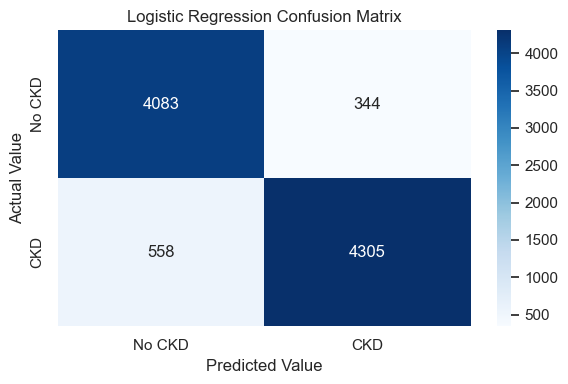

['models/logisticRegressionModel.pkl']

In [ ]:
# Logistic Regression uses scaled features.
logisticRegressionModel = LogisticRegression(
    solver="saga",
    C=0.5,
    max_iter=2000,
    random_state=42
)


# Suppress Runtime warnings for clean output.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    # Evaluate the Logistic Regression model and save its results and predictions.
    logisticRegressionResults, logisticRegressionPredictions = evaluateModel(
        "Logistic Regression",
        logisticRegressionModel,
        XTrainScaled,
        XTestScaled,
        yTrain,
        yTest
    )
joblib.dump(logisticRegressionModel, "models/logisticRegressionModel.pkl")


#### Train Random Forest

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4427
           1       0.94      0.87      0.90      4863

    accuracy                           0.90      9290
   macro avg       0.90      0.90      0.90      9290
weighted avg       0.91      0.90      0.90      9290



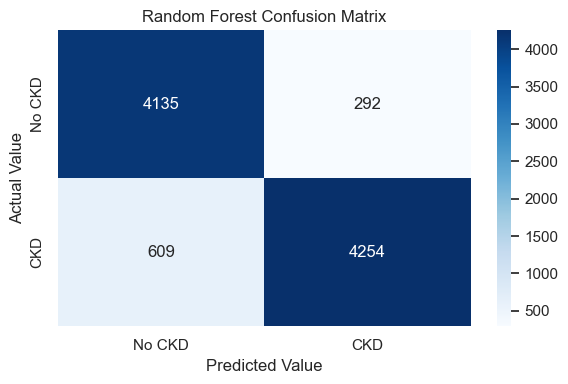

['models/randomForestModel.pkl']

In [5]:
# Random Forest uses unscaled features.
randomForestModel = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Evaluate the Random Forest model and save its results and predictions.
randomForestResults, randomForestPredictions = evaluateModel(
    "Random Forest",
    randomForestModel,
    XTrain,
    XTest,
    yTrain,
    yTest
)
joblib.dump(randomForestModel, "models/randomForestModel.pkl")

#### Train XGBoost

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4427
           1       0.94      0.88      0.91      4863

    accuracy                           0.91      9290
   macro avg       0.91      0.91      0.91      9290
weighted avg       0.91      0.91      0.91      9290



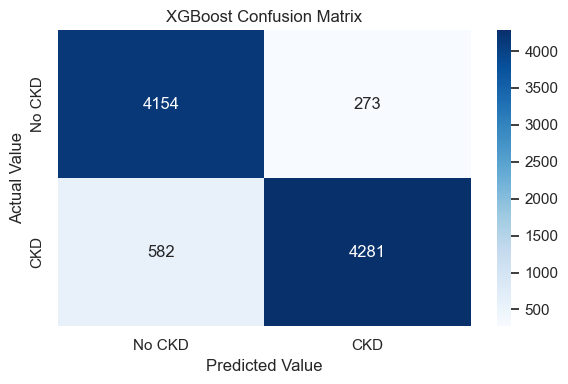

['models/xgBoostModel.pkl']

In [6]:
# XGBoost uses unscaled features.
xGBoostModel = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# Evaluate the XGBoost model and save its results and predictions.
xGBoostResults, xGBoostPredictions = evaluateModel(
    "XGBoost",
    xGBoostModel,
    XTrain,
    XTest,
    yTrain,
    yTest
)
joblib.dump(xGBoostModel, "models/xgBoostModel.pkl")

#### Save Model Results

In [7]:
# Save all model metrics and predictions for later comparison.
modelResults = pd.DataFrame([
    logisticRegressionResults,
    randomForestResults,
    xGBoostResults
])

modelResults.to_csv("outputs/modelResults.csv", index=False)

modelResults

,modelName,accuracy,precision,recall,f1Score,rocAuc
0,Logistic Regression,0.902906,0.926006,0.885256,0.905172,0.960720
1,Random Forest,0.903014,0.935768,0.874769,0.904241,0.959727
2,XGBoost,0.907966,0.940053,0.880321,0.909207,0.965443
